# Machine Learning - Spring 2026
## Homework 2

Instructor: Dr. Ilia Tetin


Student ID: 11461304a

Student Name: Ethan Zohn Bustillo

In [135]:
import shutil
shutil.copy('/kaggle/input/datasets/daichichichu/homework2a/descents.py','/kaggle/working/descents.py')
shutil.copy('/kaggle/input/datasets/daichichichu/homework2a/linear_regression_1 (3).py','/kaggle/working/linear_regression.py')

'/kaggle/working/linear_regression.py'

In [136]:
import numpy as np
import sklearn
from sklearn.metrics import mean_squared_error as mse
from linear_regression import MSELoss, CustomLinearRegression, AnalyticSolutionOptimizer


### About the assignment

In this task, you will implement the training of a linear regression model using several variants of gradient-based optimization. In `descents.py`, you are expected to complete a set of classes corresponding to different optimization strategies:

* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`

In `linear_regression.py`, you will need to implement the `CustomLinearRegression` class, which will handle both fitting the linear regression model and generating predictions for the target variable based on the learned parameters.

### About the proposed architecture

The provided template structure follows SOLID-style design principles. Its main advantage is that you can combine different loss functions and optimizers without rewriting the surrounding logic of the other classes. This is achieved by separating responsibilities clearly and relying on interfaces rather than hard-coded implementations. In Python, these interfaces are represented through abstract base classes.

At a high level, the architecture consists of four main interfaces (some of which are also represented directly by concrete base classes), each defining its own family of components:

* `interfaces.LossFunction`
  Classes implementing this interface are responsible for a specific loss function used during training, along with all behavior tied to that choice: loss computation, gradient calculation, and, when applicable, an analytical solution provided through an appropriate mixin.

* `interfaces.LinearRegressionInterface`
  This is the wrapper interface for the linear regression model itself. It acts as a container that combines the main components (the loss function and the optimizer) and uses them to perform the actual training and prediction workflow.

* `interfaces.LearningRateSchedule`
  A small family of schedules that determine the learning rate at each optimization step.

* `interfaces.AbstractOptimizer`
  Classes implementing this interface define a particular optimization algorithm and everything related to its execution. They interact with the linear regression wrapper to access the data and trigger the necessary computations, which keeps them independent of any specific loss function or learning-rate schedule.

The idea of passing small, self-contained objects into a more complex object so that each one handles its own narrow responsibility is known as **dependency injection**. This works effectively because each component is built around a well-defined interface rather than a specific implementation.

Take a look at `linear_regression.CustomLinearRegression`: it accepts objects implementing the `LossFunction` and `AbstractOptimizer` interfaces. In turn, `descents.BaseDescent`, which refines the abstract optimizer into an iterative optimization base class, receives a learning-rate scheduler during initialization.

Because of this structure, client code can proceed step by step:

* create the desired learning-rate scheduler with the required parameters;
* create the optimizer, passing in its configuration together with the scheduler;
* create the linear regression model with the appropriate loss function and the prepared optimizer;
* start the training process.

At each stage, one component can be replaced with another compatible implementation, and the rest of the system will continue to work seamlessly.

**As you work through this assignment, you will extend all of these class families with multiple implementations and swap them in and out with ease.**

For a more detailed overview of class inheritance in Python, see:

* Inheritance: `https://docs.python.org/3/tutorial/classes.html#inheritance`
* Abstract classes: `https://docs.python.org/3/library/abc.html`


### Gradient of the MSE Loss Function

In the seminar on matrix and vector differentiation, you were expected to discuss how to differentiate the MSE loss in matrix form.

### Task 1.0. MSE Gradient in Matrix Form (0.3 points)

Recall that the MSE loss can be written as

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} (y_i - \langle x_i, w \rangle)^2
= \frac{1}{\ell} |Xw - y|^2
$$

where $\ell$ is the number of training samples, $X \in \mathbb{R}^{\ell \times d}$ is the feature matrix, and $y \in \mathbb{R}^{\ell}$ is the target vector. The notation $x_i$ refers to the $i$-th row of $X$, corresponding to the $i$-th sample.

* **Write down the gradient of the MSE loss in matrix form** (either from the seminar notes or by deriving it yourself).

**Solution:**
$$
derivation --- > below
$$
* **Implement the methods `MSELoss.loss` and `MSELoss.gradient`**
  L(w) = 1/n ∑ from i=1 to n (yi'−yi)^2


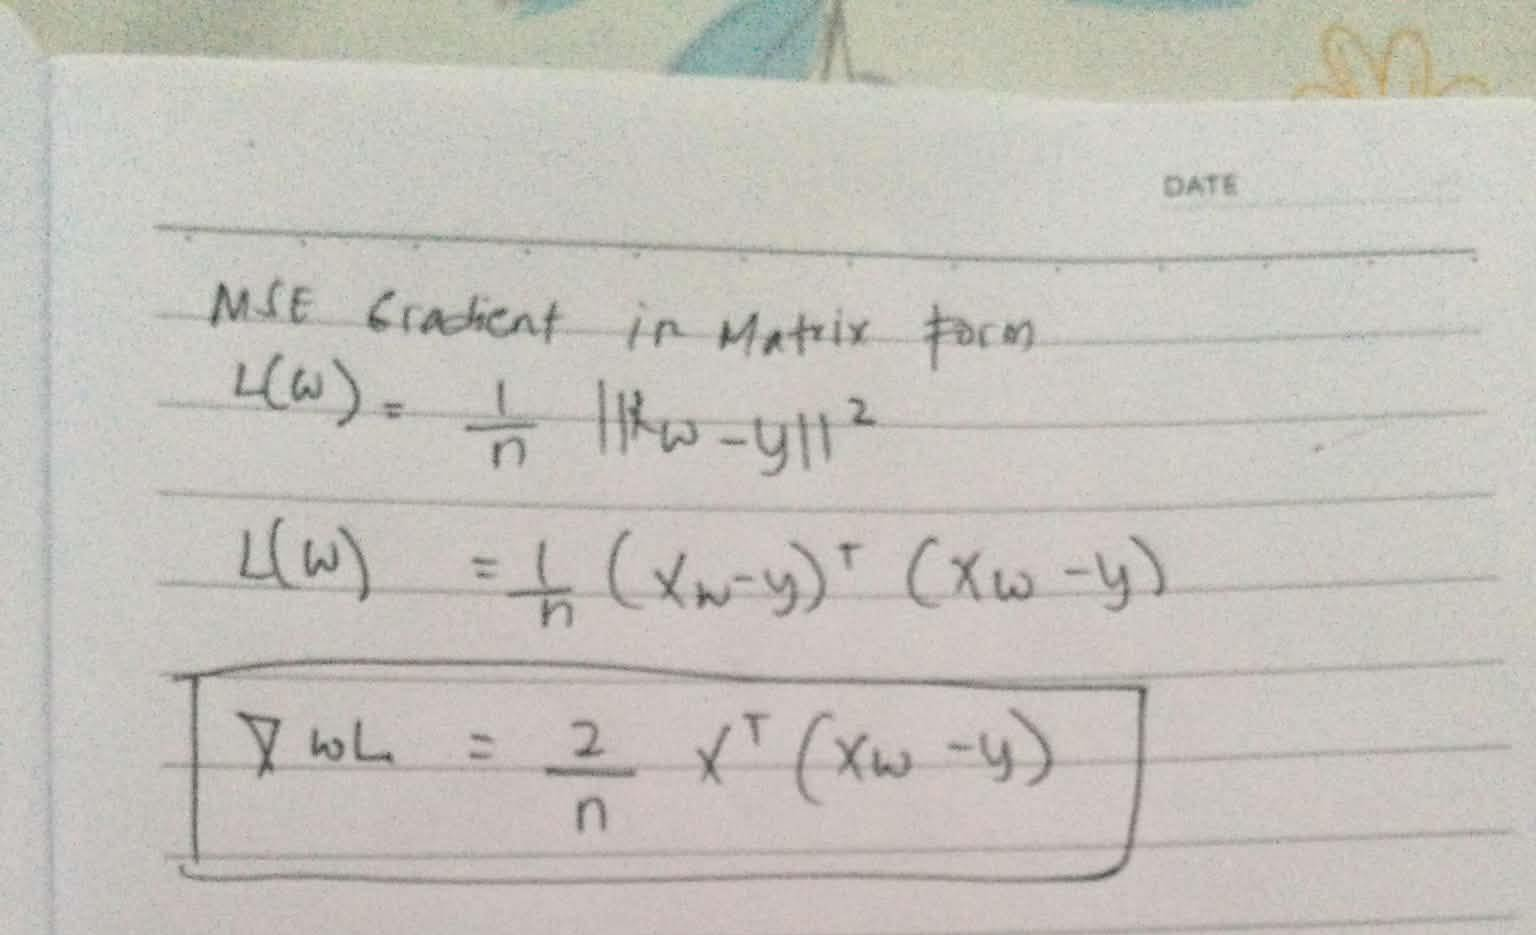

In [137]:
from IPython.display import Image
Image('/kaggle/input/datasets/daichichichu/image0/8b8b9da7-7d6e-49e5-9e9a-cf02049f2903.jpg')

#example in coding
def compute_gradients(self, X, y):
    errors = X @ self.weights - y        # (Xw - y)
    return (2 / len(y)) * X.T @ errors  # (2/n) * X^T * (Xw - y)

def loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    n = len(y)
    total = 0.0
    for i in range(n):
        prediction = 0.0
        for j in range(len(w)):
            prediction += X[i, j] * w[j]   # x_i^T @ w
        error = prediction - y[i]           # (x_i^T w - y_i)
        total += error ** 2                 # (x_i^T w - y_i)^2
    return total / n                        # 1/n * sum

def gradient(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    n = len(y)
    grad = np.zeros(len(w))
    for i in range(n):
        prediction = 0.0
        for j in range(len(w)):
            prediction += X[i, j] * w[j]   # x_i^T @ w
        error = prediction - y[i]           # (x_i^T w - y_i)
        for j in range(len(w)):
            grad[j] += error * X[i, j]     # accumulate (error * x_ij)
    return (2 / n) * grad                  # 2/n * sum 
    
 

### Task 1.1. Closed-Form Solution and `CustomLinearRegression` (0.7 points)

Before moving on to iterative optimization methods, let us recall that for some loss functions an analytical solution also exists. First, let us revisit what that solution looks like for MSE.

* **Derive the formula for the optimal $w$ in the MSE minimization problem and write it below.**
* **Implement this computation in `MSELoss._plain_analytic_solution`**

$$
\text{MSE} = |Xw - y|^2
$$

$$
w = (X^T X)^-1 X^T y  
$$
** derivation below **
     


* **Question:** As we know, the analytical solution has several drawbacks. What are they?

**Answer:** Ill-Conditioning and Numerical Stability. Ill-conditioning happens when X^T X features are highly correlated or often known as multicollinearity. This makes the analytical solution numerically unstable.

Now let us connect this solution to our linear regression class so that the overall architecture becomes clearer.

* **Complete the class `descents.AnalyticSolutionOptimizer`**
* **Complete the class `CustomLinearRegression`**

  * At this stage, you should implement all of its methods: `fit` and `predict` will be needed immediately, while `compute_gradients` and `compute_loss` will be used in the next part.

Keep in mind the separation of responsibilities between classes.

The optimizer is responsible for controlling the training procedure, while the linear regression object mainly serves as an entry point, a container for the data, and an access layer for the computations that the optimizer relies on, such as the gradient direction at the current parameter values.

At the same time, the optimizer itself should remain generic: it should not contain any logic specific to a particular loss function. Everything it needs should be accessible through `self.model`.

Similarly, the linear regression class should also remain generic and be ready to work with any loss function and any optimizer that follows the required interface. This is an example of dependency injection, and your implementation should preserve that design properly. In the same way, anything your model needs from the loss function should be obtained by calling the corresponding methods of the injected loss object.


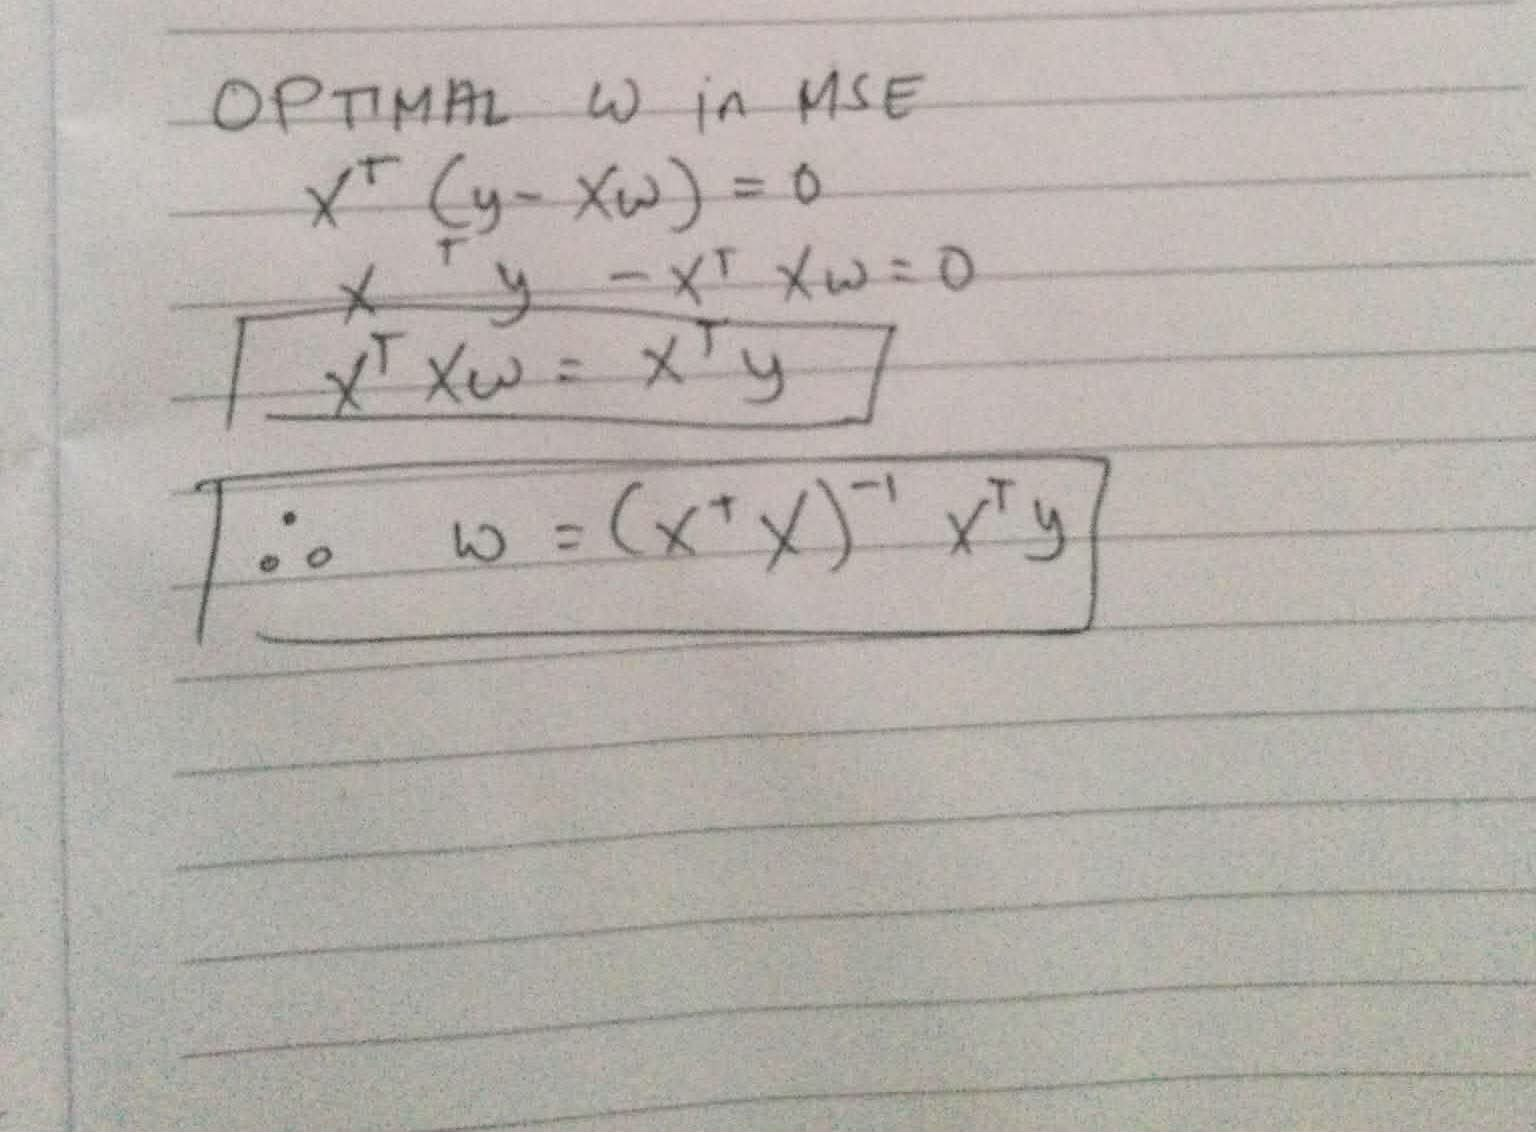

In [138]:
Image('/kaggle/input/datasets/daichichichu/image0/cbcb16d5-39e2-497d-bd28-72d2676fbb6b.jpg')

In [139]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"

Sklearn MSE 0.09962138675859018
Your MSE 0.09962138675859018


In [140]:
x[:, 3] = x[:, 2] + x[:, 4]

In [141]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.1027016769566792
Your MSE 0.1027016769566792


Let’s make this part a bit more interesting by modifying one of the assumptions. As we know, exact multicollinearity prevents us from using the standard closed-form solution directly, yet `sklearn` somehow still manages to handle such cases. Your goal is to figure out how to make the analytical solution well-defined for **any** matrix $X$, regardless of rank deficiency. It turns out this can be done using an SVD-based formulation. For the implementation, use `scipy.sparse.linalg.svds`.

* Derive the SVD-based expression for the optimal $w$ in the MSE minimization problem.

* Implement this computation in `MSELoss._svd_analytic_solution`.

  * Numerical linear algebra can be tricky. If you inspect the available options in `svds`, you will notice that computing the full spectrum with exact precision is not really the intended use case. Use the default solver and set the highest available numerical accuracy.

* Answer the **bonus theory question**. In some settings, including this one, even an apparently imperfect SVD computation can still recover the exact solution to the problem. Explain why this happens. What is this variant of SVD called? What is the minimum number of singular values that is sufficient, with probability 1, to recover the exact solution in our case? Justify your answer.

$$
X = \underset{n \times m}{U}\ \underset{m \times m}{\Sigma}\ \underset{m \times k}{V^T}
$$

$$
derivation ---> below
$$

**Answer:**
The least-squares solution remains robust because it is governed strictly by the matrix's column space and its nonzero singular directions. While minor numerical errors during Singular Value Decomposition (SVD) may slightly perturb the singular values themselves, they rarely distort the fundamental subspace structure, leaving the rank and dominant singular vectors intact. Ultimately, the stability of the pseudoinverse is guaranteed as long as the system's rank is accurately determined and the signal space remains cleanly separated from the null space to prevent noise from leaking into the solution.

This is called the **Truncated SVD** (or sometimes the Compact SVD if only non-zero singular values are kept). By using scipy.sparse.linalg.svds, it is explicitly calculating a truncated version by specifying a $k$ number of singular values. In this case, the minimum value that is sufficient is **4**. Initially, the matrix $X$ has a dimension of 5. Since it is populated with random floats, its initial rank is 5 with probability 1.The code then introduces exact multicollinearity: x[:, 3] = x[:, 2] + x[:, 4]. This makes the 4th column a linear combination of the 3rd and 5th, reducing the rank of the matrix to 4. In SVD, the number of non-zero singular values equals the rank of the matrix. Therefore, 4 singular values are sufficient to capture the entire "signal" of the column space and reconstruct the exact solution, while the 5th singular value (which would be 0 or near-zero due to noise) represents the null space and is discarded.


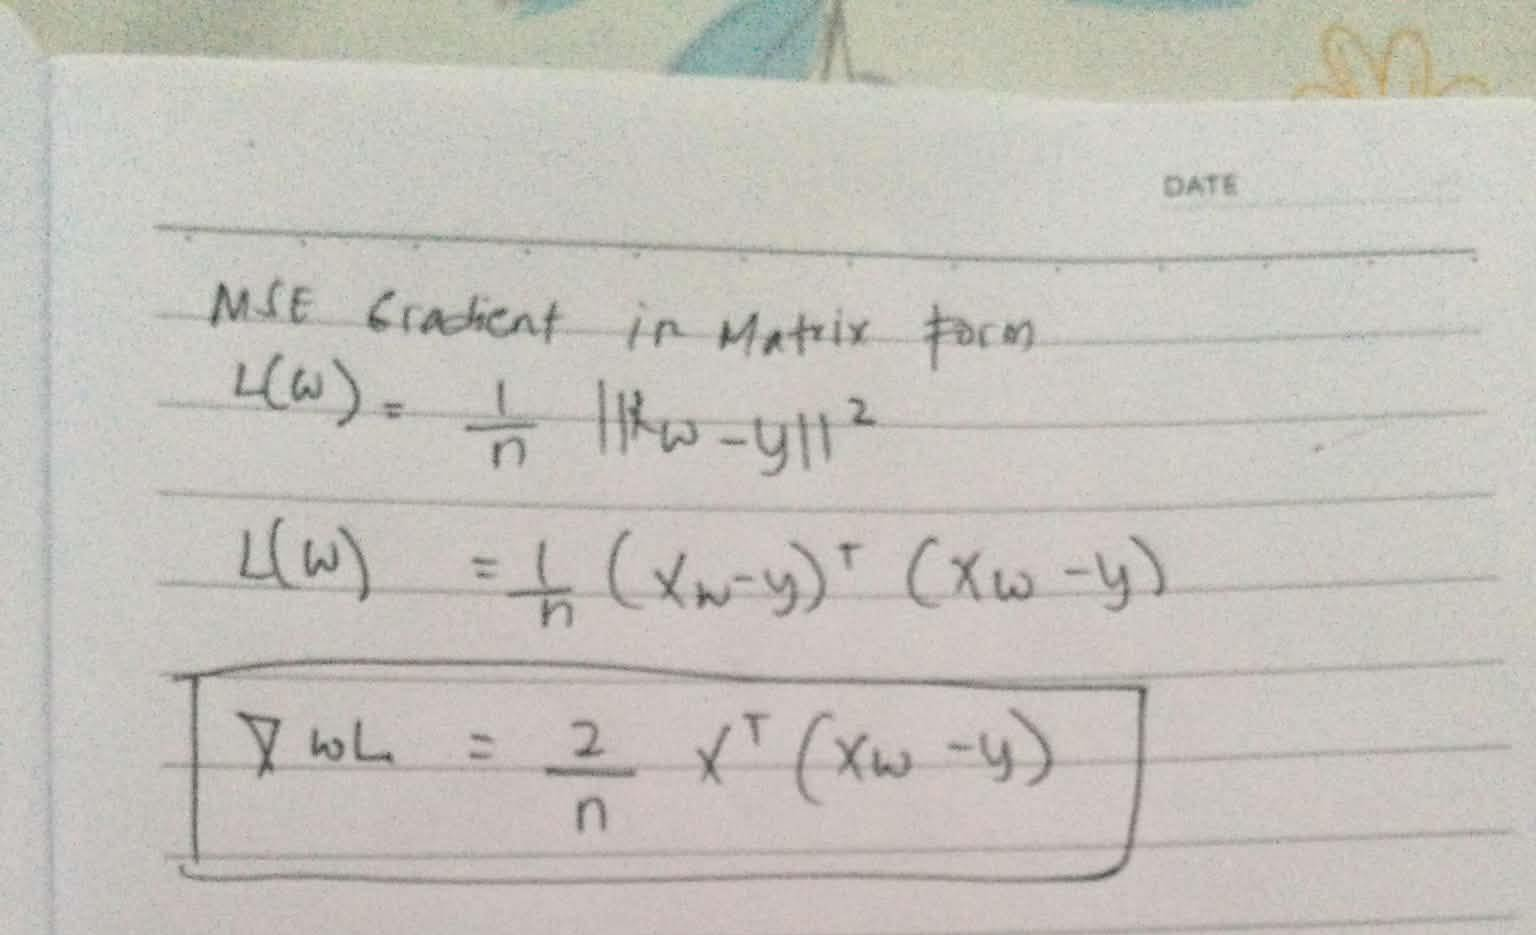

In [142]:
Image('/kaggle/input/datasets/daichichichu/image0a/8b8b9da7-7d6e-49e5-9e9a-cf02049f2903 (1).jpg')

In [143]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"

Sklearn MSE 0.1027016769566792
Your MSE 0.1027016769566792


## Task 2. Implementing Gradient Descent (4 points)

In this part, you will build your own implementations of several gradient-based optimization methods using the prepared templates in `descents.py`. These optimizers will then be plugged into `CustomLinearRegression` to obtain iterative solutions.

### Reminder: gradient descent

The key property of the negative gradient is that it points in the direction of the **steepest decrease** of the objective at the current point. Naturally, this suggests the following strategy: start from some initial parameter vector, move in the direction of the negative gradient, recompute it at the new point, and repeat until convergence.

Formally, let $w_0$ be the initial parameter vector (for example, zeros or a random initialization). Then vanilla gradient descent consists of repeating

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

Here, $\eta_k$ is the step size at iteration $k$ (the learning rate), and $Q(w)$ is the loss function.

You have already derived the gradient of MSE above.

### Task 2.0. Learning Rate Schedules (0.2 points)

Take a look at the **abstract** class `LearningRateSchedule` in `descents.py`. Its implementations are used to produce the appropriate learning rate $\eta_k$ at each iteration of gradient descent.

The file already includes `ConstantLR`, which returns the same fixed step size every time. Your task here is to implement `TimeDecayLR`, which we will use for linear regression training. The step size should follow

$$
\eta_k = \lambda \left(\frac{s_0}{s_0 + k}\right)^p
$$

In practice, it is usually enough to tune only $\lambda$, while keeping the default values $s_0 = 1$ and $p = 0.5$.





### Task 2.1. The parent class `BaseDescent` (1 point)

Study the structure of `BaseDescent` carefully. Although it is an abstract base for iterative optimizers, it still contains one method that must be implemented: `optimize`.

* **Complete the method `BaseDescent.optimize`.**

This method should contain the main optimization loop, which will then be reused by all subclasses.

For this part and everything that follows, the implementation must satisfy these requirements:

* **All computations must be vectorized;**
* Python loops are allowed only for the outer optimization iterations;
* Use the following stopping criteria simultaneously:

  * the squared Euclidean norm of the difference between consecutive weight vectors is smaller than `tolerance`;
  * the weight difference contains `NaN` values;
  * the number of iterations reaches `max_iter`.
* You may assume that the input data already contains a column of ones as the last feature column;
* Model weights must be updated inside `_update_weights` — that method name is intentional;
* To monitor convergence, use `CustomLinearRegression.loss_history`, storing:

  * the loss value **before each update**, starting from iteration zero (before the first gradient step),
  * and the final loss value **after optimization finishes**.

Note that `_update_weights` is still abstract, so it must be implemented by the subclasses. Its role is to update `self.model.w` and return the actual update vector

$$
w_{k+1} - w_k.
$$

Also pay attention to `self.iteration`, which stores the current iteration number. Together with `self.lr_schedule`, it is used to obtain the correct learning rate for each step.

### Important note

Yes, one more time:

All descent classes you implement in this assignment are meant to be **generic optimizers**. They must not compute gradients of a specific loss function internally.

Whenever an optimizer needs a gradient, it should always ask the model:

```python
gradient = self.model.compute_gradients(X_batch, y_batch)
```

### Task 2.2. Full gradient descent: `VanillaGradientDescent` (0.6 points)

Implement full-batch gradient descent by filling in the missing parts of `VanillaGradientDescent` in `descents.py`.

Recall that the update rule for classical gradient descent is

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

**Important:** here and below, `_update_weights` must return the difference between the new and old weights:

$$
w_{k+1} - w_k = -\eta_k \nabla_w Q(w_k).
$$

As its name suggests, it must also update `model.w`.

### Reminder: SGD (stochastic gradient descent)

In many machine learning problems, the objective $Q(w)$ can be written as a sum of $\ell$ terms:

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} q_i(w).
$$

In our assignment, each function $q_i(w)$ corresponds to the error contribution of a single training example.

The drawback of standard gradient descent is that each step requires computing the gradient of the full sum:

$$
\nabla_w Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} \nabla_w q_i(w).
$$

For large datasets, this can be expensive. In practice, however, an exact gradient is often unnecessary: since the update step is usually not too large, a noisy approximation often works well enough.

A common approximation is to average gradients over a randomly chosen subset of samples:

$$
\nabla_w Q(w_k) \approx \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k),
$$

where $B$ is a random subset of indices, usually called a **batch**.

This estimate is known as a **stochastic gradient**, and the resulting method is called **stochastic gradient descent**, or simply SGD.

### Task 2.3. Stochastic gradient descent: `StochasticGradientDescent` (0.7 points)

Implement stochastic gradient descent by completing the missing parts of `StochasticGradientDescent`.

Use the mini-batch gradient estimate above. The update rule becomes

$$
w_{k+1} = w_k - \eta_k \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k).
$$

The batch size should be treated as a **hyperparameter** and passed through the class constructor `__init__(...)`.

You may sample batch indices with replacement using `np.random.randint` — this is acceptable and yields an unbiased gradient estimate. Sampling without replacement is also fine, for example via `np.random.choice(..., replace=False)` or by shuffling across epochs.


### Task 2.4. Stochastic Average Gradient (0.6 points)
Now consider the SAG method. We keep in memory the most recent individual gradients $g_i$ for all training examples, as well as their average

$$
\bar g = \frac{1}{\ell} \sum_i g_i.
$$

At each step, we choose indices $j$ (a mini-batch), recompute the corresponding gradients $g_j^{new}(w_k)$, and update the running average as

$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr), \qquad
w_{k+1} = w_k - \eta_k \bar g.
$$

Initialization is

$$
g_i = 0 \Rightarrow \bar g = 0.
$$

This gives us updates that resemble full-gradient descent, while only recomputing gradients for a small number of samples on each iteration.

Implement `SAGDescent` in `descents.py` using `grad_memory` and `avg_grad`.

A useful trick: to obtain a per-sample gradient, you can call `compute_gradients` either on a slice containing a single sample, `X[j:j+1]`, or on a matrix formed from the selected batch indices.

**Keep in mind that SAG can be quite sensitive**: its convergence and practical speed depend noticeably on the batch size. A default value is provided, but on real datasets it may not be enough. In later comparisons, you may need to tune the batch size to see the method perform well. The same applies to SGD, although usually to a lesser extent.

### A quick reminder: Momentum (inertia) method

Sometimes the negative gradient direction changes too sharply from one step to the next. For instance, if the level sets of the objective are highly elongated, then because the gradient is orthogonal to those level sets, its direction may flip almost to the opposite side at every iteration. Such oscillations add a lot of noise to the trajectory and slow optimization down significantly.

To reduce this effect, we can average the negative gradients from several previous steps. This smooths out the noise and makes the update direction reflect the overall trend of motion more accurately. For that, we introduce the **momentum vector**:

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k)
\end{align}

Here, $\alpha$ is the momentum coefficient controlling how quickly information from previous steps decays. Naturally, instead of the exact gradient, one may also use its approximation, for example in the case of **stochastic gradient descent**.

Then the parameter update is simply performed by moving against the new momentum vector:

$$
w_{k+1} = w_k - h_{k+1}.
$$

Notice that if the gradient along a certain coordinate keeps changing sign, then after averaging, that coordinate of the momentum vector will tend to stay close to zero. On the other hand, if the gradient along some coordinate consistently keeps the same sign, then the corresponding momentum component will grow larger, leading to bigger steps in that direction.



### Task 2.5. Momentum method — `MomentumDescent` (0.5 points)

Implement gradient descent with momentum by filling in the missing parts of the `MomentumDescent` class. The update rule is

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k), \
&w_{k+1} = w_k - h_{k+1}.
\end{align}

The parameter $\alpha$ is a hyperparameter of the method, but in this assignment it is fixed for you at $\alpha = 0.9$.

### A quick reminder: AdaGrad, RMSProp, and Adam

Gradient descent is highly sensitive to the choice of step size. If the step is too large, the algorithm may overshoot the minimum; if it is too small, convergence may take far too many iterations. Moreover, there is usually no reliable way to know the optimal learning rate in advance, and even schedules that gradually shrink it can behave poorly.

In **AdaGrad**, a separate effective step size is introduced for each coordinate of the parameter vector. The idea is simple: accumulate the sum of squared gradients and divide the current gradient by the square root of that sum. As a result, coordinates with consistently large gradients get smaller updates, while coordinates with smaller gradients receive relatively larger ones. The update rule is

\begin{align}
&G_{k j} = G_{k-1, j} + \left(\nabla_w Q(w_{k-1})\right)*j^2, \
&w*{j k} = w_{j, k-1} - \frac{\eta_k}{\sqrt{G_{k j}} + \varepsilon} \left(\nabla_w Q(w_{k-1})\right)_j.
\end{align}

Here, $\varepsilon$ is a small constant used to prevent division by zero.

In this method, it is often possible to keep the learning rate fixed, for example $\eta_k = 0.01$, rather than tuning it during training **(note that in this assignment, the learning rate is not fixed)**. AdaGrad is especially useful for sparse problems, where most features are zero for most samples. Features that appear only rarely receive relatively large updates, while frequently active features get smaller ones.

However, AdaGrad has a major drawback: the accumulator $G_{k j}$ grows monotonically, so the updates become smaller and smaller over time, potentially stopping progress before the true minimum is reached.

This issue is addressed in **RMSProp**, which replaces the cumulative sum with an exponentially decaying average:

$$
G_{k j} = \alpha G_{k-1, j} + (1 - \alpha)\left(\nabla_w Q(w^{(k-1)})\right)_j^2.
$$

With this modification, the step size along each coordinate depends mostly on how actively that coordinate has been changing in recent iterations.

We can combine these ideas: accumulate gradients over previous steps to reduce oscillations (**momentum**), while also adapting the step size for each parameter individually (**RMSProp**-style scaling). This leads to the **Adam** method, with the additional feature that Adam uses bias correction for both the first and second moment estimates.

### Task 2.6. Adam (Adaptive Moment Estimation) (0.4 points)

Implement gradient descent with Adam by filling in the missing parts of the `Adam` class. The update rule is

\begin{align}
&m_0 = 0, \quad v_0 = 0; \ \
&m_{k+1} = \beta_1 m_k + (1 - \beta_1)\nabla_w Q(w_k); \ \
&v_{k+1} = \beta_2 v_k + (1 - \beta_2)\left(\nabla_w Q(w_k)\right)^2; \ \
&\widehat{m}*{k} = \dfrac{m_k}{1 - \beta_1^k}, \quad \widehat{v}*{k} = \dfrac{v_k}{1 - \beta_2^k}; \ \
&w_{k+1} = w_k - \dfrac{\eta_k}{\sqrt{\widehat{v}*{k+1}} + \varepsilon}\widehat{m}*{k+1}.
\end{align}

In this assignment, the constants are fixed as follows:

$$
\beta_1 = 0.9, \qquad \beta_2 = 0.999, \qquad \varepsilon = 10^{-8}.
$$

## Task 3. Code sanity check (0 points)

This section is intended to help you verify that your implementations of the optimization methods and the `CustomLinearRegression` class behave correctly. To begin with, we will run a small local check to make sure your models are at least producing reasonable outputs and can be executed without errors.


In [144]:
%load_ext autoreload

ModuleNotFoundError: No module named 'imp'

In [ ]:
import sys

autoreload_path = "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py"

with open(autoreload_path, "r") as f:
    content = f.read()

# Replace the broken import with the modern equivalent
content = content.replace("from imp import reload", "from importlib import reload")

with open(autoreload_path, "w") as f:
    f.write(content)

print("Patched successfully!")

In [ ]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [ ]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [ ]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


## Task 4. Working with the data (1 point)

In this part, we will use a dataset of car sale listings from German eBay. Our prediction target will be the **price**.

* Plot the distribution of the target variable and decide whether applying a logarithmic transformation would make sense.

* Check whether the dataset contains price outliers or clearly abnormal values. If such observations are present, remove them.

* Perform an exploratory data analysis:

  * inspect the column types and visualize both the distribution of feature values and the relationship between each feature and the target;
  * think about which features appear useful based on these plots, and handle outliers where appropriate;
  * consider which feature transformations would be reasonable to apply, and explain your choices;
  * split the useful features into three groups: categorical, numerical, and those that do not require preprocessing.

* Split the data into training, validation, and test sets in the ratio **8:1:1**.

In [ ]:
import numpy as np
import pandas as pd  # you may replace this with polars, pyspark, or any other tool you prefer

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

data = pd.read_csv('/kaggle/input/datasets/daichichichu/homework2a/autos (1).csv')  # if you are not using pandas, adjust this accordingly
data.head()


In [ ]:
data.shape

In [145]:
data.info()           # Data types and missing values
data.describe()       # Statistical summary for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241190 entries, 0 to 241189
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   brand              241190 non-null  object
 1   model              241190 non-null  object
 2   vehicleType        241190 non-null  object
 3   gearbox            241190 non-null  object
 4   fuelType           241190 non-null  object
 5   notRepairedDamage  241190 non-null  object
 6   powerPS            241190 non-null  int64 
 7   kilometer          241190 non-null  int64 
 8   autoAgeMonths      241190 non-null  int64 
 9   price              241190 non-null  int64 
 10  bias               241190 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 20.2+ MB


,powerPS,kilometer,autoAgeMonths,price,bias
count,241190.000000,241190.000000,241190.000000,241190.000000,241190.0
mean,131.271628,123766.677723,144.768676,6887.741892,1.0
std,60.622613,39825.955933,73.092598,8024.451993,0.0
min,51.000000,5000.000000,1.000000,1.000000,1.0
25%,90.000000,100000.000000,92.000000,1750.000000,1.0
50%,120.000000,150000.000000,140.000000,4100.000000,1.0
75%,160.000000,150000.000000,192.000000,8999.000000,1.0
max,589.000000,150000.000000,600.000000,99999.000000,1.0


### Columns in the dataset

* `brand` — the car manufacturer

* `model` — the specific car model

* `vehicleType` — the body or vehicle category

* `gearbox` — the transmission type

* `fuelType` — the type of fuel the car uses

* `notRepairedDamage` — whether the car has unrepaired damage

* `powerPS` — engine power measured in PS (metric horsepower)

* `kilometer` — the mileage of the car in kilometers

* `autoAgeMonths` — the age of the car in months

* `price` — the listed selling price of the car (**target variable**)

Group the features into **categorical**, **numerical**, and **other / no special preprocessing needed** categories.



In [146]:
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []

# Print groupings
print("=" * 50)
print("GROUPED FEATURES")
print("=" * 50)

print("\n CATEGORICAL:")
print("  - brand")
print("  - model")
print("  - vehicleType")
print("  - gearbox")
print("  - fuelType")
print("  - notRepairedDamage")

print("\n NUMERIC:")
print("  - powerPS")
print("  - kilometer")
print("  - autoAgeMonths")

print("\n OTHER:")
print("  ")

GROUPED FEATURES

 CATEGORICAL:
  - brand
  - model
  - vehicleType
  - gearbox
  - fuelType
  - notRepairedDamage

 NUMERIC:
  - powerPS
  - kilometer
  - autoAgeMonths

 OTHER:
  


Add a constant column called `bias` to the dataset so that the model can absorb the intercept term directly, instead of introducing a separate parameter $b$ for it.


In [147]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price']

print("=" * 50)
print("GROUPED FEATURES")
print("=" * 50)
print("\n CATEGORICAL:")
print("  - brand")
print("  - model")
print("  - vehicleType")
print("  - gearbox")
print("  - fuelType")
print("  - notRepairedDamage")
print("\n NUMERIC:")
print("  - powerPS")
print("  - kilometer")
print("  - autoAgeMonths")
print("\n OTHER:")
print("  - bias")

GROUPED FEATURES

 CATEGORICAL:
  - brand
  - model
  - vehicleType
  - gearbox
  - fuelType
  - notRepairedDamage

 NUMERIC:
  - powerPS
  - kilometer
  - autoAgeMonths

 OTHER:
  - bias


Now you need to split the dataset into **training**, **validation**, and **test** subsets. After that, apply some basic preprocessing:

* apply `OneHotEncoder` to the categorical features;
* standardize the numerical features using `StandardScaler`;
* leave the remaining features unchanged, since there is no clear transformation strategy for them at this stage.

> Why do we split the data first and only then apply preprocessing?
> Because encoders and scalers learn properties of the data during `fit`. If you fit them on the full dataset before splitting, information from the validation and test sets leaks into training. That would introduce data leakage, since statistics from held-out data would influence the model-building process.


In [148]:
sklearn?

Type:        module
String form: <module 'sklearn' from '/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py'>
File:        /usr/local/lib/python3.12/dist-packages/sklearn/__init__.py
Docstring:   Configure global settings and get information about the working environment.


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ('num', StandardScaler(), numeric), # z=(x−μ)/σ uses this formula
],  remainder='passthrough') 


x_train = preprocessor.fit_transform(x_train)
x_val   = preprocessor.transform(x_val)
x_test  = preprocessor.transform(x_test)
total = x_train.shape[0] + x_val.shape[0] + x_test.shape[0]


print(f"Train size:      {x_train.shape[0]}")
print(f"Validation size: {x_val.shape[0]}")
print(f"Test size:       {x_test.shape[0]}")
print(f"Total:      {total}")

## Task 5. Comparing gradient-based optimization methods (1.5 points)

In this part, you will compare the optimization methods on the processed dataset prepared in the previous task.

### Task 5.1. Selecting the best learning-rate scale (0.75 points)

For each optimization method, choose the best value of the step-size scale parameter $\lambda$ using the validation set, based on predictive error. To do this, run a search over a logarithmic grid of candidate values.

For every method, report:

* the error on the training set;
* the error on the test set;
* the $R^2$ score;
* the number of iterations required for convergence.

All parameters other than `lambda_` should be left at their default values.


In [ ]:
print(x.shape)
print(y.shape)
print(x.columns.tolist())

In [162]:
from descents import (VanillaGradientDescent, StochasticGradientDescent,
                      SAGDescent, MomentumDescent, Adam, TimeDecayLR)
from linear_regression import CustomLinearRegression, MSELoss
from sklearn.metrics import r2_score

lambda_grid = np.logspace(-6, -1, 10)

optimizers = {
    'VanillaGD': VanillaGradientDescent,
    'SGD': StochasticGradientDescent,
    'SAG': SAGDescent,
    'Momentum': MomentumDescent,
    'Adam': Adam,
}

results = {}

for name, OptimizerClass in optimizers.items():

    best_lambda = None
    best_val_mse = np.inf
    best_model = None

    for lam in lambda_grid:

        lr = TimeDecayLR(lambda_=lam)
        opt = OptimizerClass(lr_schedule=lr, max_iter=100)
        model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())
        model.fit(x_train, y_train.values)

        val_mse = model.compute_loss(x_val, y_val.values)
        print(f"{name} lam={lam:.2e} val_mse={val_mse}")

        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_lambda = lam
            best_model = model

    if best_model is None:
        print(f"{name}: all lambdas failed, skipping")
        continue

    train_mse = best_model.compute_loss(x_train, y_train.values)
    test_mse = best_model.compute_loss(x_test, y_test.values)
    score = r2_score(y_test.values, best_model.predict(x_test))
    n_iter = len(best_model.loss_history) - 1

    results[name] = {
        'best_lambda': best_lambda,
        'train_mse': train_mse,
        'val_mse': best_val_mse,
        'test_mse': test_mse,
        'r2_score': score,
        'n_iter': n_iter,
        'best_model': best_model
    }

print(f"\n{'Method':<12} {'lambda':>10} {'Train MSE':>12} {'Test MSE':>12} {'R2':>8} {'Iters':>8}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:<12} {r['best_lambda']:>10.2e} {r['train_mse']:>12.2f} {r['test_mse']:>12.2f} {r['r2_score']:>8.4f} {r['n_iter']:>8}")

VanillaGD lam=1.00e-06 val_mse=1.1787768652125718e+159
VanillaGD lam=3.59e-06 val_mse=1.1611311720897535e+159
VanillaGD lam=1.29e-05 val_mse=1.0998897147498962e+159
VanillaGD lam=4.64e-05 val_mse=9.054997382101955e+158
VanillaGD lam=1.67e-04 val_mse=4.515987735466536e+158
VanillaGD lam=5.99e-04 val_mse=3.859450912660999e+157
VanillaGD lam=2.15e-03 val_mse=8.995871740880315e+153
VanillaGD lam=7.74e-03 val_mse=7.853342135648979e+142
VanillaGD lam=2.78e-02 val_mse=7.627675896904116e+115
VanillaGD lam=1.00e-01 val_mse=1.2199238328228888e+64
SGD lam=1.00e-06 val_mse=4.3228803035458063e+148
SGD lam=3.59e-06 val_mse=2.2266610315338543e+149
SGD lam=1.29e-05 val_mse=3.627068552665773e+147
SGD lam=4.64e-05 val_mse=2.7005991539737926e+153
SGD lam=1.67e-04 val_mse=4.061173997288879e+137
SGD lam=5.99e-04 val_mse=4.223039134616259e+140
SGD lam=2.15e-03 val_mse=1.6802410004657162e+149
SGD lam=7.74e-03 val_mse=6.224872644744238e+132
SGD lam=2.78e-02 val_mse=3.572834095428859e+105
SGD lam=1.00e-01 val_

In [ ]:
print("any nan in x_train:", np.any(np.isnan(x_train)))
print("any inf in x_train:", np.any(np.isinf(x_train)))
print("any nan in y_train:", np.any(np.isnan(y_train)))
print("any inf in y_train:", np.any(np.isinf(y_train)))
print("x_train max:", np.max(np.abs(x_train)))
print("y_train max:", np.max(np.abs(y_train)))

### Task 5.2. Comparing the optimization methods (0.75 points)

Plot the training error as a function of the iteration number, showing **all methods on the same figure**.

Then examine the resulting outputs — both the metric tables and the convergence plot — and compare the methods to one another.

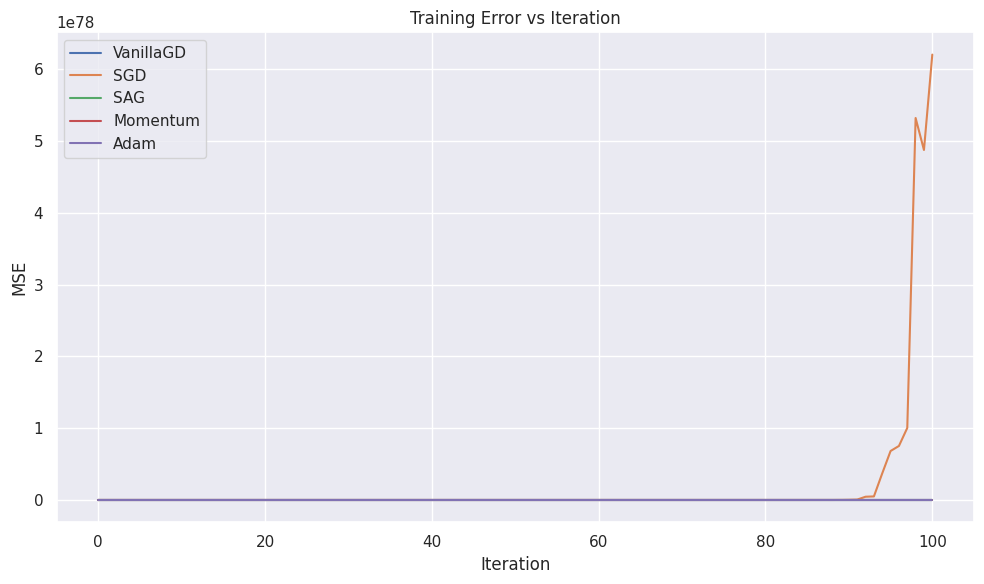

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, r in results.items():
    plt.plot(r['best_model'].loss_history, label=name)

plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Training Error vs Iteration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

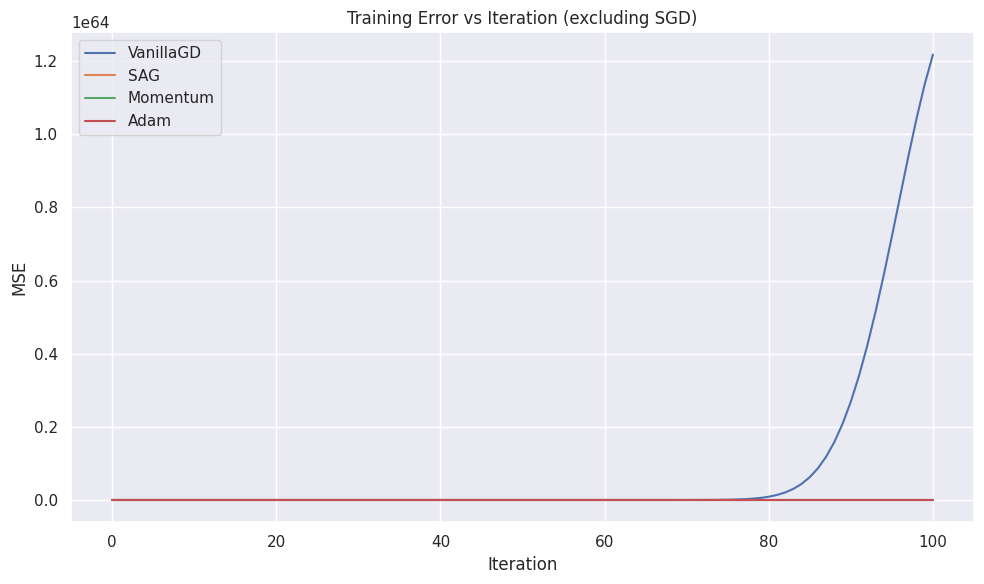

In [164]:
plt.figure(figsize=(10, 6))

for name, r in results.items():
    if name == 'SGD':
        continue  # skipping SGD
    plt.plot(r['best_model'].loss_history, label=name)

plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Training Error vs Iteration (excluding SGD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 6. Stochastic gradient descent and batch size (1 point)

In this task, you will study how the mini-batch size affects the behavior of stochastic gradient descent.

* Run SGD several times for each batch size from a chosen list of values (for example, $k = 10$ runs per batch size) on the training set.
* Measure the runtime in seconds and the number of iterations needed to reach convergence.
* For each batch size, compute the average runtime and the average number of iterations.

Then:

* Plot the dependence of the number of iterations to convergence on the batch size.
  *(Here, convergence means that the stopping criterion is met.)*
* Plot the dependence of the runtime to convergence on the batch size.

After that, analyze the results. What conclusions can you draw about choosing the batch size for SGD?

In [151]:
x_train = preprocessor.fit_transform(x_train)
x_val   = preprocessor.transform(x_val)
x_test  = preprocessor.transform(x_test)

print(type(x_train))  # should be <class 'numpy.ndarray'>

<class 'numpy.ndarray'>


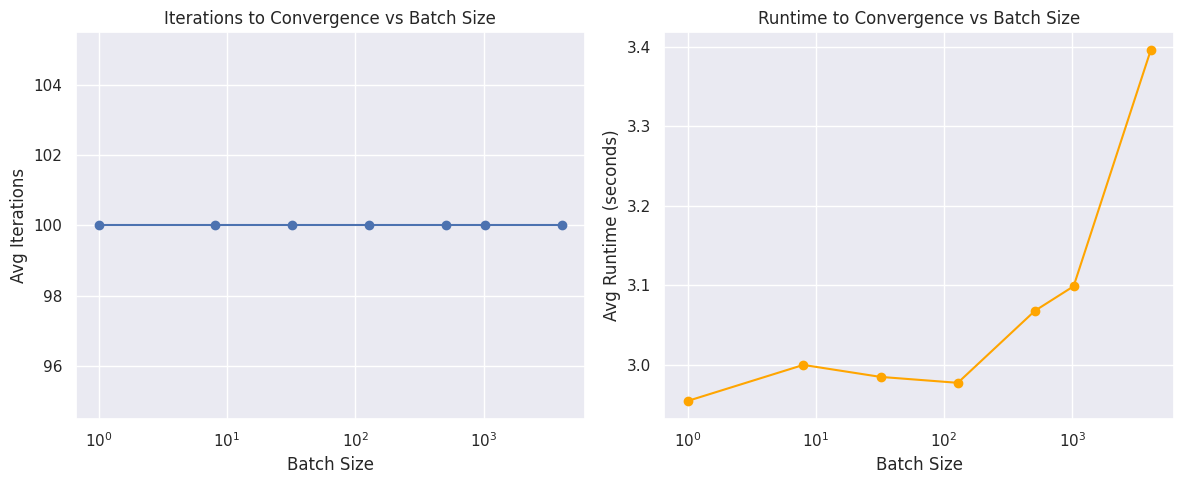

In [152]:
import time

batch_sizes = [1, 8, 32, 128, 512, 1024, 4096]
runs_per_batch = 5

batch_results = {}

for batch_size in batch_sizes:

    iter_list = []
    time_list = []

    for run in range(runs_per_batch):
        lr = TimeDecayLR(lambda_=results['SGD']['best_lambda'])
        opt = StochasticGradientDescent(lr_schedule=lr, batch_size=batch_size, max_iter=100)
        model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())

        start = time.time()
        model.fit(x_train, y_train.values)
        end = time.time()

        iter_list.append(len(model.loss_history) - 1)
        time_list.append(end - start)

    avg_iter = np.mean(iter_list)
    avg_time = np.mean(time_list)

    batch_results[batch_size] = {
        'avg_iter': avg_iter,
        'avg_time': avg_time
    }

batch_sizes_list = list(batch_results.keys())
avg_iters = [batch_results[b]['avg_iter'] for b in batch_sizes_list]
avg_times = [batch_results[b]['avg_time'] for b in batch_sizes_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(batch_sizes_list, avg_iters, marker='o')
ax1.set_xscale('log')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Avg Iterations')
ax1.set_title('Iterations to Convergence vs Batch Size')
ax1.grid(True)

ax2.plot(batch_sizes_list, avg_times, marker='o', color='orange')
ax2.set_xscale('log')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Avg Runtime (seconds)')
ax2.set_title('Runtime to Convergence vs Batch Size')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 7. Regularization (0.5 points)

In this part, you will investigate how regularization affects different gradient-based optimization methods.

Recall that regularization adds a penalty term to the loss function that discourages large weights. We will use **$L_2$ regularization**, so the objective becomes

$$
Q(w) = \dfrac{1}{\ell} \sum_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} |w|^2
$$

Complete the class `linear_regression.L2Regularization` according to the provided interface and documentation.

Using the regularized loss in your experiments, find the best training parameters in the same spirit as in Task 5. This time, tune both the learning-rate scale $\lambda$ (`lambda_`) and the regularization strength $\mu$ (`mu`).

For each method, compare the results **with** and **without** regularization. Again, report:

* the error on the training set,
* the error on the test set,
* the $R^2$ score on both sets,
* the number of iterations until convergence.

Also, for each method, plot the value of the loss function across iterations for the regularized and non-regularized versions. In total, you should obtain **five plots**.

Finally, interpret the results. What can you conclude about the influence of regularization on convergence? How did the training quality change? What happened on the test set? How would you explain these effects?


Method           lambda         mu    Train MSE     Test MSE       R2    Iters
---------------------------------------------------------------------------
VanillaGD      1.00e-01   1.00e-04 523813369703323890570760564261252746964390912095944704.0000 525210830971019379755122739012731412981683109037604864.0000 -546325225054370012199193417217897470335732671475351552.0000      100
SGD            1.00e-01   3.59e-01 115241373784298383706897091706983086152946802569731567549002285056.0000 114717828971731022905533538042714035006025055318860763837545578496.0000 -101444126952684655477374447801198070970344724580179841543110131712.0000      100
SAG            4.64e-05   5.99e-03       0.8722       0.8365   0.1299      100
Momentum       1.00e-06   1.00e-04       0.2807       0.2690   0.7205      100
Adam           2.15e-03   1.00e-04       0.2604       0.2517   0.7409      100


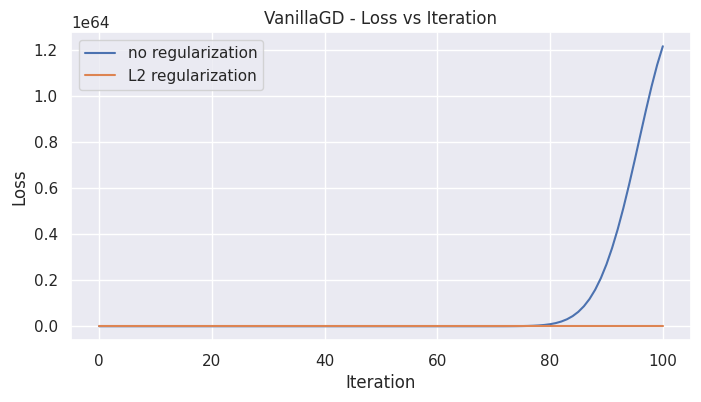

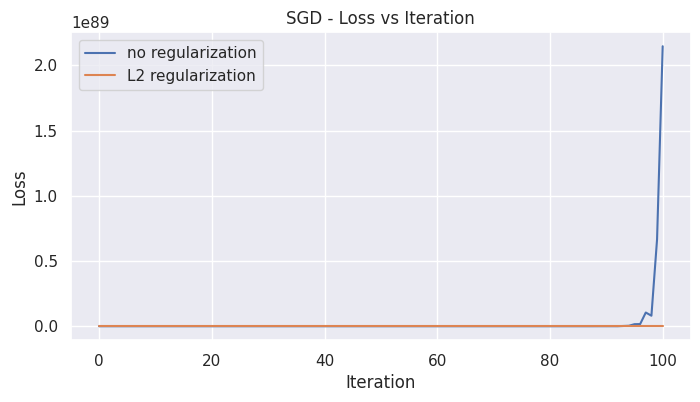

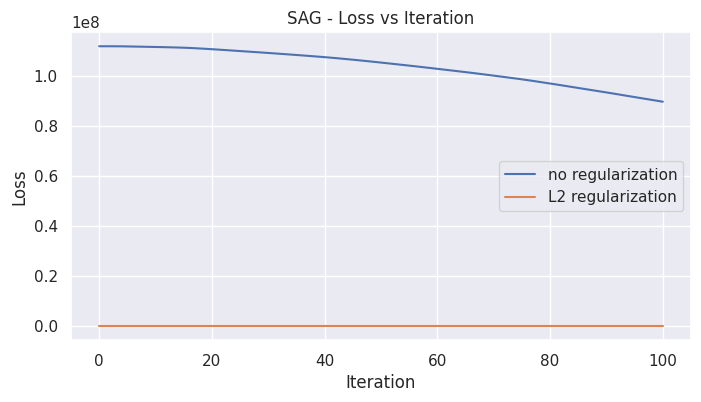

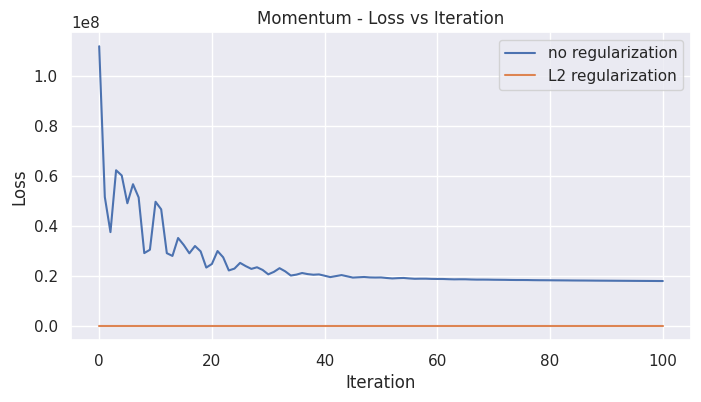

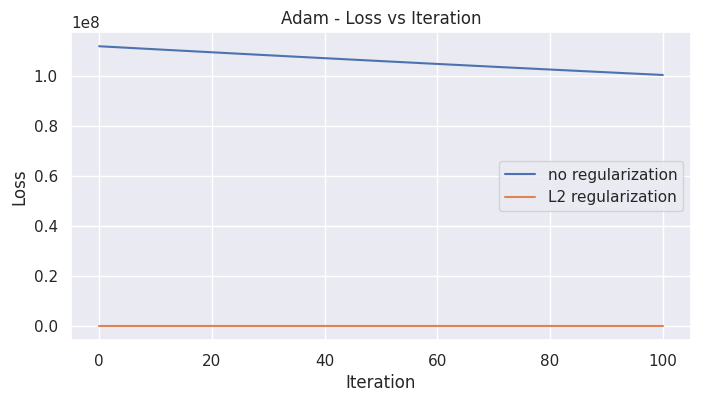

In [157]:
from linear_regression import CustomLinearRegression, MSELoss, L2Regularization
from sklearn.metrics import r2_score

lambda_grid = np.logspace(-6, -1, 10)
mu_grid = np.logspace(-4, 0, 10)

optimizers = {
    'VanillaGD': VanillaGradientDescent,
    'SGD': StochasticGradientDescent,
    'SAG': SAGDescent,
    'Momentum': MomentumDescent,
    'Adam': Adam,
}

results_reg = {}

for name, OptimizerClass in optimizers.items():

    best_lambda = None
    best_mu = None
    best_val_mse = np.inf
    best_model = None

    for lam in lambda_grid:
        for mu in mu_grid:

            lr = TimeDecayLR(lambda_=lam)
            opt = OptimizerClass(lr_schedule=lr, max_iter=100)
            loss = L2Regularization(MSELoss(), mu=mu)
            model = CustomLinearRegression(optimizer=opt, loss_function=loss)
            model.fit(x_train, y_train_scaled)

            val_mse = model.compute_loss(x_val, y_val_scaled)

            if np.isnan(val_mse) or np.isinf(val_mse):
                continue

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_lambda = lam
                best_mu = mu
                best_model = model

    if best_model is None:
        print(f"{name}: all lambdas failed, skipping")
        continue

    train_mse = best_model.compute_loss(x_train, y_train_scaled)
    test_mse = best_model.compute_loss(x_test, y_test_scaled)
    score = r2_score(y_test_scaled, best_model.predict(x_test))
    n_iter = len(best_model.loss_history) - 1

    results_reg[name] = {
        'best_lambda': best_lambda,
        'best_mu': best_mu,
        'train_mse': train_mse,
        'val_mse': best_val_mse,
        'test_mse': test_mse,
        'r2_score': score,
        'n_iter': n_iter,
        'best_model': best_model
    }

print(f"\n{'Method':<12} {'lambda':>10} {'mu':>10} {'Train MSE':>12} {'Test MSE':>12} {'R2':>8} {'Iters':>8}")
print("-" * 75)
for name, r in results_reg.items():
    print(f"{name:<12} {r['best_lambda']:>10.2e} {r['best_mu']:>10.2e} {r['train_mse']:>12.4f} {r['test_mse']:>12.4f} {r['r2_score']:>8.4f} {r['n_iter']:>8}")

for name in results_reg.keys():
    plt.figure(figsize=(8, 4))
    if name in results:
        plt.plot(results[name]['best_model'].loss_history, label='no regularization')
    plt.plot(results_reg[name]['best_model'].loss_history, label='L2 regularization')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(f'{name} - Loss vs Iteration')
    plt.legend()
    plt.grid(True)
    plt.show()

## Task 8. Alternative loss functions (1 point)

In this task, you will replace MSE with different regression losses. We will consider **LogCosh** and **HuberLoss**.

The LogCosh loss is defined as

$$
L(y, a) = \log\bigl(\cosh(a - y)\bigr).
$$

The Huber loss is defined as

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
\frac{1}{2}(a_i - y_i)^2, & \text{if } |a_i - y_i| < \delta, \
\delta |a_i - y_i| - \frac{1}{2}\delta^2, & \text{if } |a_i - y_i| \ge \delta.
\end{cases}
$$

Derive the gradients of these loss functions manually.
You are expected to show not only the final expressions, but also the intermediate steps.

**Solution:**

   Solution below


Then implement these loss functions and their gradients in `linear_regression.py`.

After that, train all five gradient-based optimization methods **without regularization** using these losses, in the same way as in Task 5, and compare the resulting quality with the earlier results obtained using MSE.

These new losses should be implemented by inheriting from `linear_regression.LossFunction` and defining all required abstract methods.

A closed-form analytical solution is **not** required for these losses.

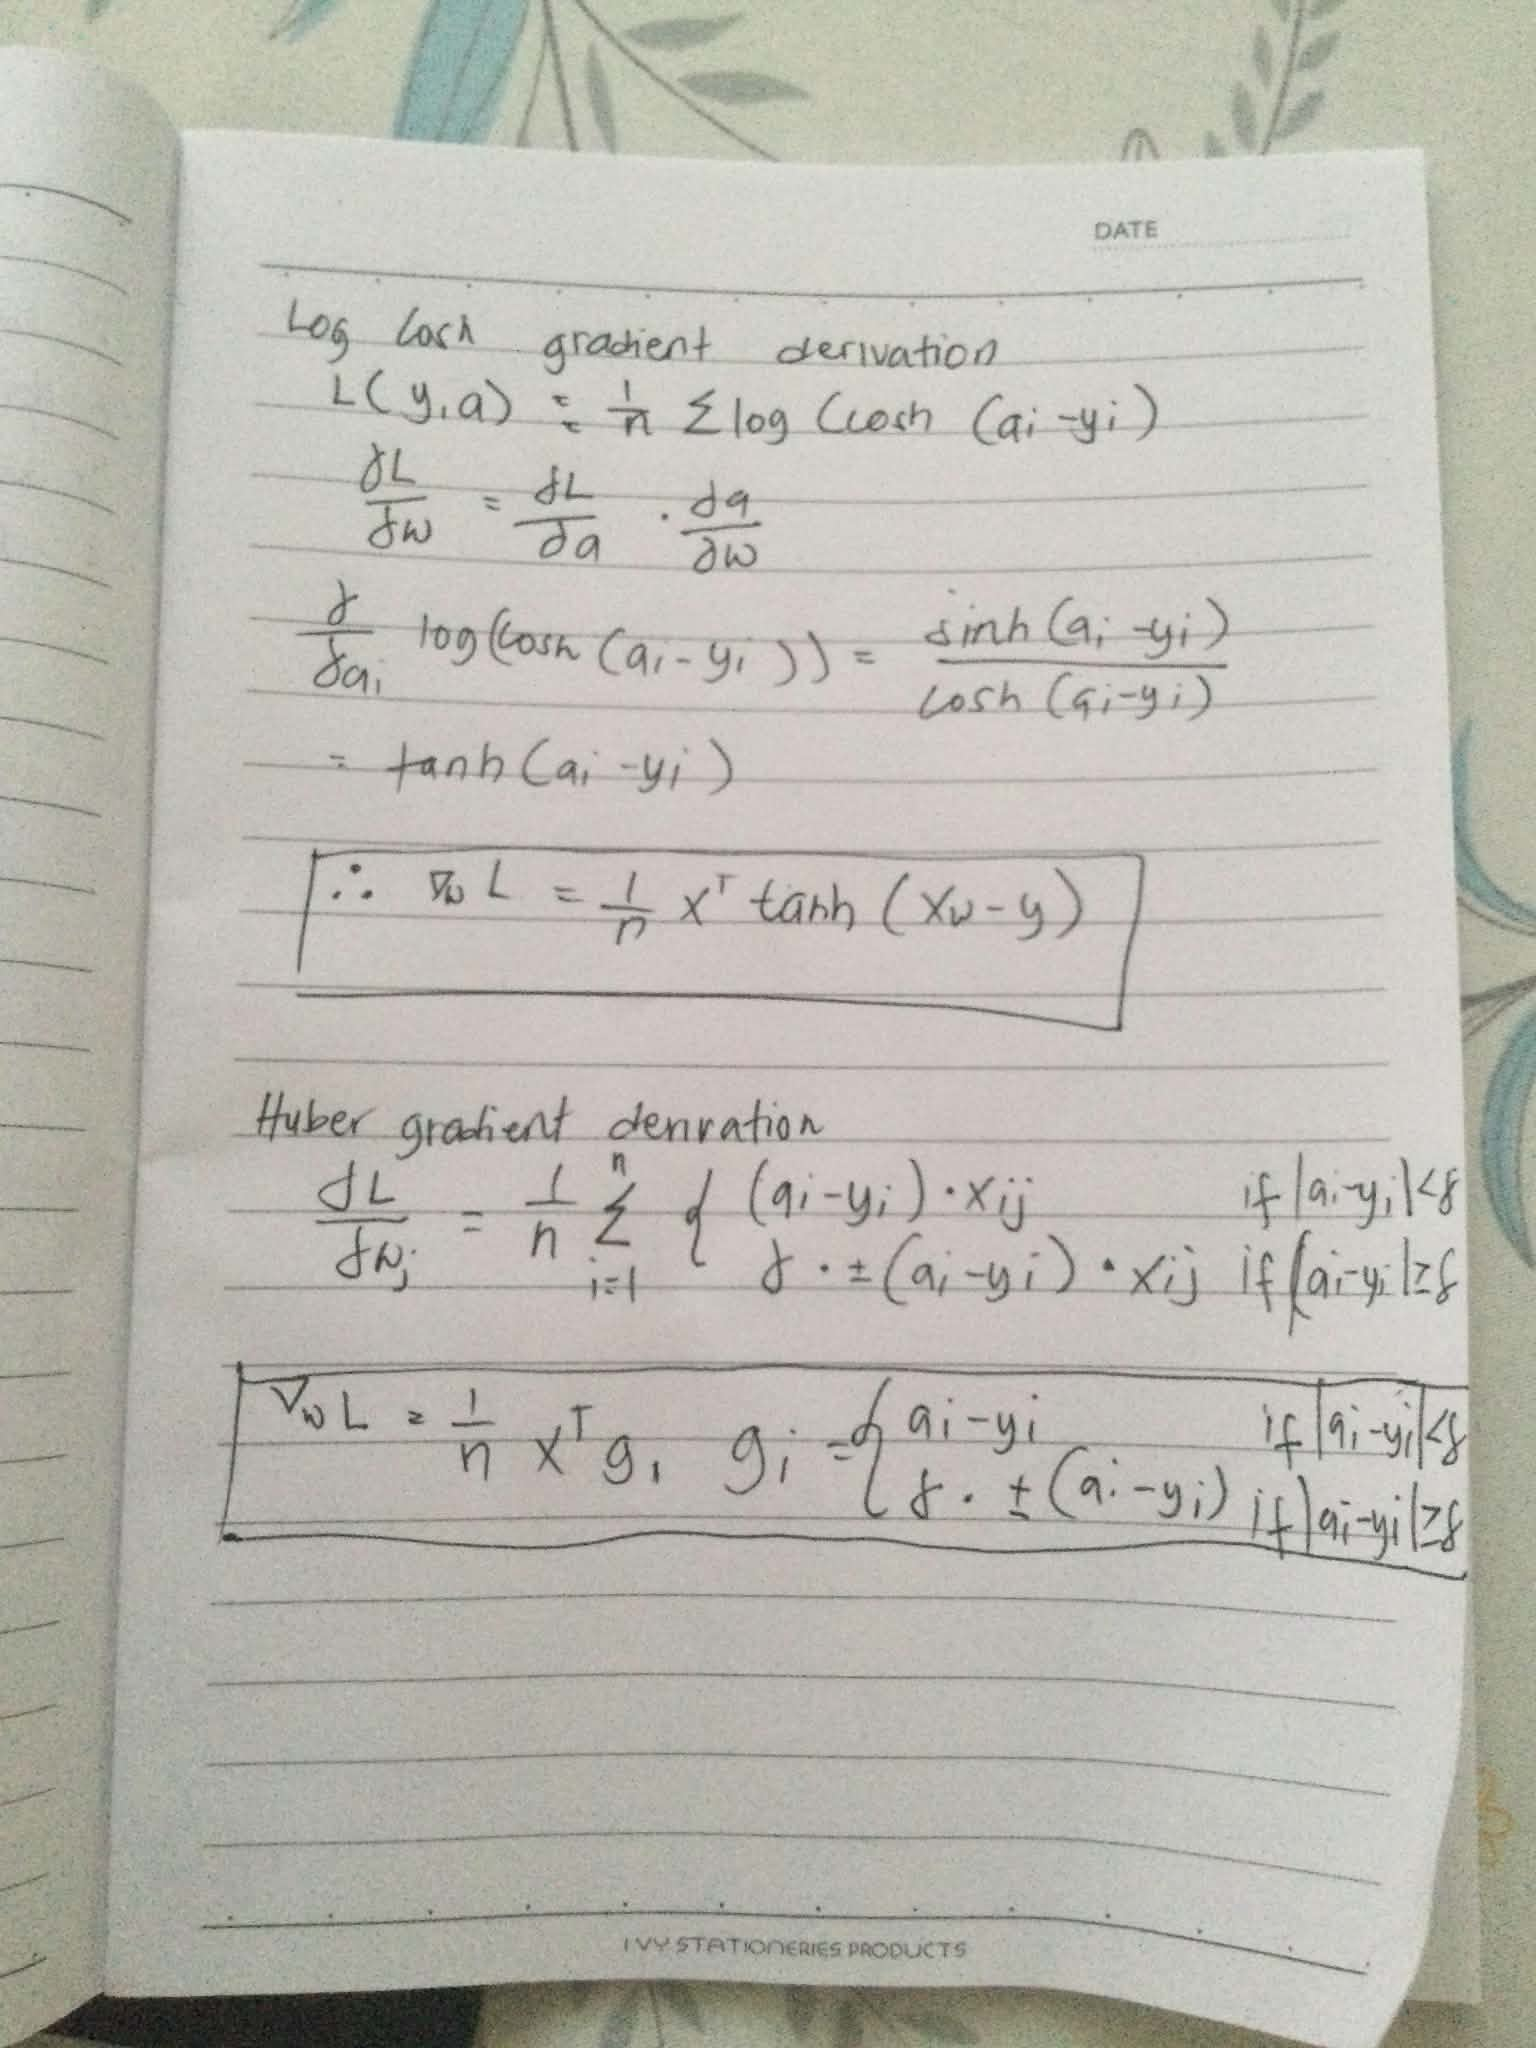

In [158]:
Image('/kaggle/input/datasets/daichichichu/image1/da461ee5-e6fe-4622-afbd-d3df2f96fa8c.jpg')

In [161]:
from linear_regression import CustomLinearRegression, MSELoss, L2Regularization, LogCoshLoss, HuberLoss
from sklearn.metrics import r2_score

lambda_grid = np.logspace(-6, -1, 10)

optimizers = {
    'VanillaGD': VanillaGradientDescent,
    'SGD': StochasticGradientDescent,
    'SAG': SAGDescent,
    'Momentum': MomentumDescent,
    'Adam': Adam,
}

loss_functions = {
    'LogCosh': LogCoshLoss(),
    'Huber': HuberLoss(delta=1.0)
}

results_alt = {}

for loss_name, loss_fn in loss_functions.items():

    results_alt[loss_name] = {}

    for name, OptimizerClass in optimizers.items():

        best_lambda = None
        best_val_mse = np.inf
        best_model = None

        for lam in lambda_grid:

            lr = TimeDecayLR(lambda_=lam)
            opt = OptimizerClass(lr_schedule=lr, max_iter=100)
            model = CustomLinearRegression(optimizer=opt, loss_function=loss_fn)
            model.fit(x_train, y_train_scaled)

            val_mse = model.compute_loss(x_val, y_val_scaled)

            if np.isnan(val_mse) or np.isinf(val_mse):
                continue

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_lambda = lam
                best_model = model

        if best_model is None:
            print(f"{loss_name} - {name}: all lambdas failed, skipping")
            continue

        train_mse = best_model.compute_loss(x_train, y_train_scaled)
        test_mse = best_model.compute_loss(x_test, y_test_scaled)
        score = r2_score(y_test_scaled, best_model.predict(x_test))
        n_iter = len(best_model.loss_history) - 1

        results_alt[loss_name][name] = {
            'best_lambda': best_lambda,
            'train_mse': train_mse,
            'val_mse': best_val_mse,
            'test_mse': test_mse,
            'r2_score': score,
            'n_iter': n_iter,
            'best_model': best_model
        }

    print(f"\n--- {loss_name} ---")
    print(f"{'Method':<12} {'lambda':>10} {'Train Loss':>12} {'Test Loss':>12} {'R2':>8} {'Iters':>8}")
    print("-" * 65)
    for name, r in results_alt[loss_name].items():
        print(f"{name:<12} {r['best_lambda']:>10.2e} {r['train_mse']:>12.4f} {r['test_mse']:>12.4f} {r['r2_score']:>8.4f} {r['n_iter']:>8}")


--- LogCosh ---
Method           lambda   Train Loss    Test Loss       R2    Iters
-----------------------------------------------------------------
VanillaGD      2.78e-02       0.1065       0.1041   0.6687      100
SGD            2.78e-02       0.9835       0.9842  -2.8627      100
SAG            7.74e-03       0.2962       0.2909   0.0000        1
Momentum       1.00e-06       0.1046       0.1021   0.6764      100
Adam           2.15e-03       0.0911       0.0893   0.7377      100

--- Huber ---
Method           lambda   Train Loss    Test Loss       R2    Iters
-----------------------------------------------------------------
VanillaGD      2.78e-02       0.1160       0.1134   0.6679      100
SGD            1.00e-01       0.4631       0.4658  -0.2918      100
SAG            1.67e-04       0.3230       0.3175   0.0000        1
Momentum       1.00e-06       0.1132       0.1106   0.6773      100
Adam           7.74e-03       0.0992       0.0971   0.7362      100
